<a href="https://colab.research.google.com/github/Agwora/Agwora/blob/main/TimeseriesModels_classwork(R).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Install and load required packages
required_packages <- c("ggplot2", "tseries", "forecast", "gridExtra", "lmtest", "reshape2")
for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg)
  }
  library(pkg, character.only = TRUE)
}

Loading required package: tseries

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘tseries’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: forecast

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘forecast’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’


Loading required package: gridExtra

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘gridExtra’”
Installing p

BOX-JENKINS METHODOLOGY FOR TIME SERIES ANALYSIS

STEP 1: Loading Time Series Data
 ---------------------------------------- 
Data loaded: 108 observations
Date range: 2017 to 2025 

STEP 2: Testing for Stationarity
 ---------------------------------------- 

 Original Series - Augmented Dickey-Fuller Test:
ADF Statistic: -3.2477 
p-value: 0.0836 
=> Series is non-stationary

STEP 3: Model Identification
 ---------------------------------------- 

Applying differencing to achieve stationarity...


Warning message in adf.test(timeseries, alternative = "stationary"):
“p-value smaller than printed p-value”



 Differenced Series - Augmented Dickey-Fuller Test:
ADF Statistic: -6.2125 
p-value: 0.01 
=> Series is stationary

STEP 4: Model Estimation and Fitting
 ---------------------------------------- 

FITTING DIFFERENT TIME SERIES MODELS

AR Model (Order p= 0 ):
AIC: 1081.86  BIC: 1086.77  RMSE: 152.4189 

MA Model (Order q= 0 ):
AIC: 1081.86  BIC: 1086.77  RMSE: 152.4189 

ARMA Model (p=1, q=1):

AIC: 1084.43  BIC: 1094.25  RMSE: 153.0376 

ARIMA Model (Order: (0,0,0):

AIC: 1081.86  BIC: 1086.77  RMSE: 152.4189 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


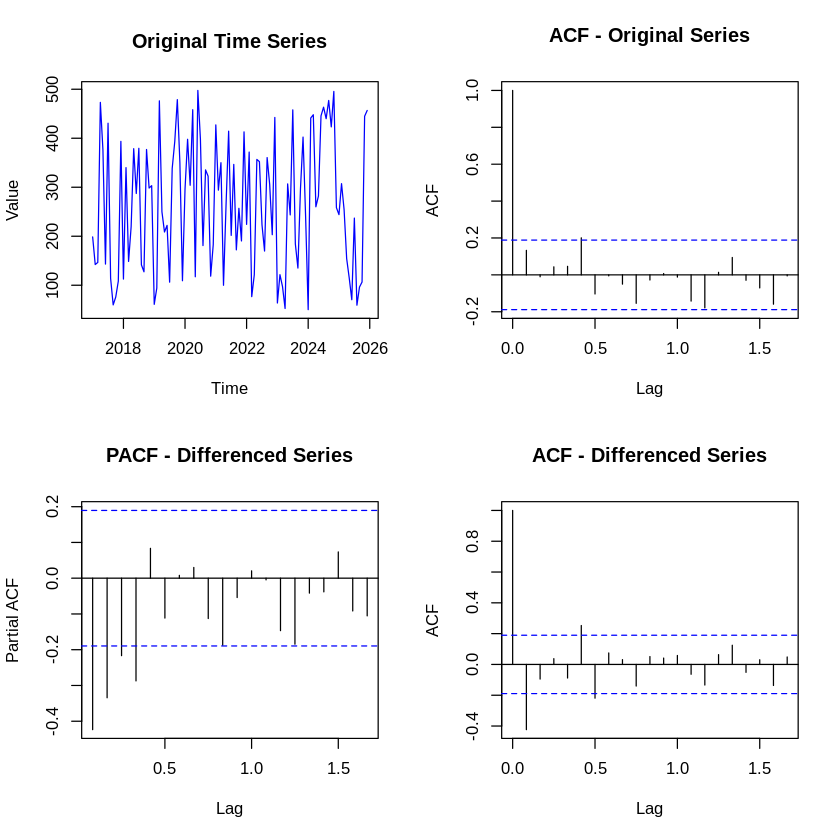


STEP 5: Diagnostic Checking
 ---------------------------------------- 

Checking residuals for AR model:

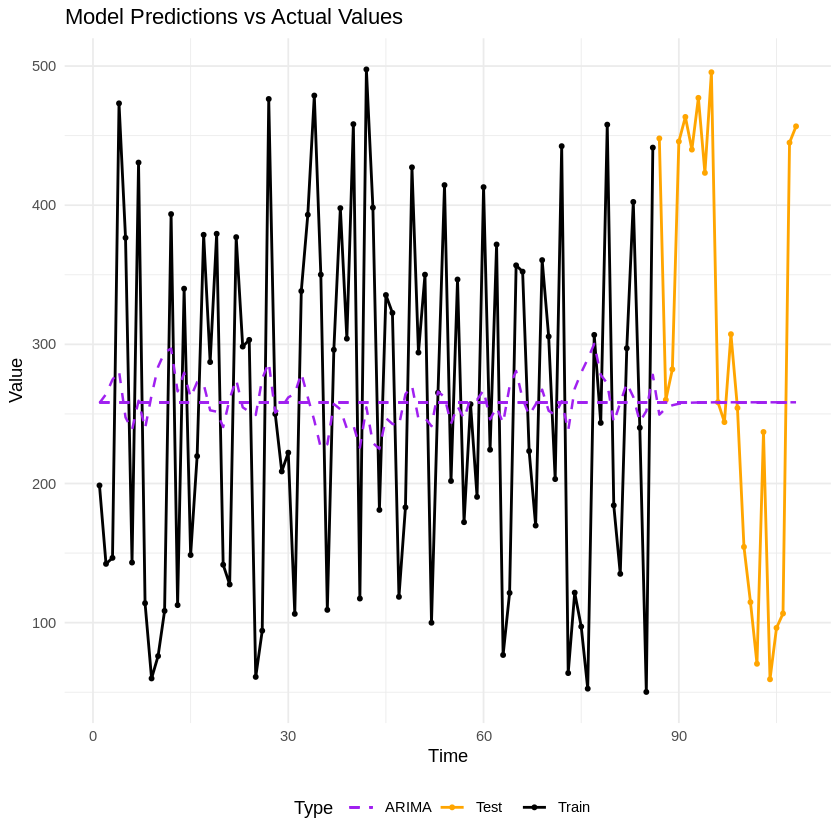


 AR - Ljung-Box Test Results:
Lag 10 - p-value: 0.3529 
Lag 20 - p-value: 0.3887 
=> Residuals appear to be white noise

Checking residuals for MA model:

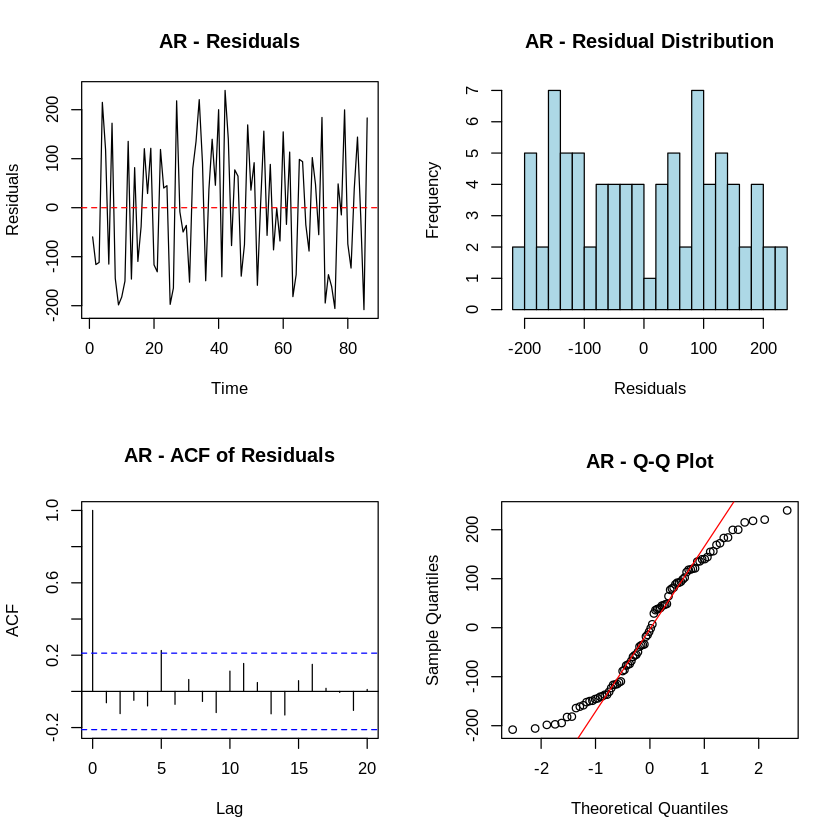


 MA - Ljung-Box Test Results:
Lag 10 - p-value: 0.3529 
Lag 20 - p-value: 0.3887 
=> Residuals appear to be white noise

Checking residuals for ARMA model:

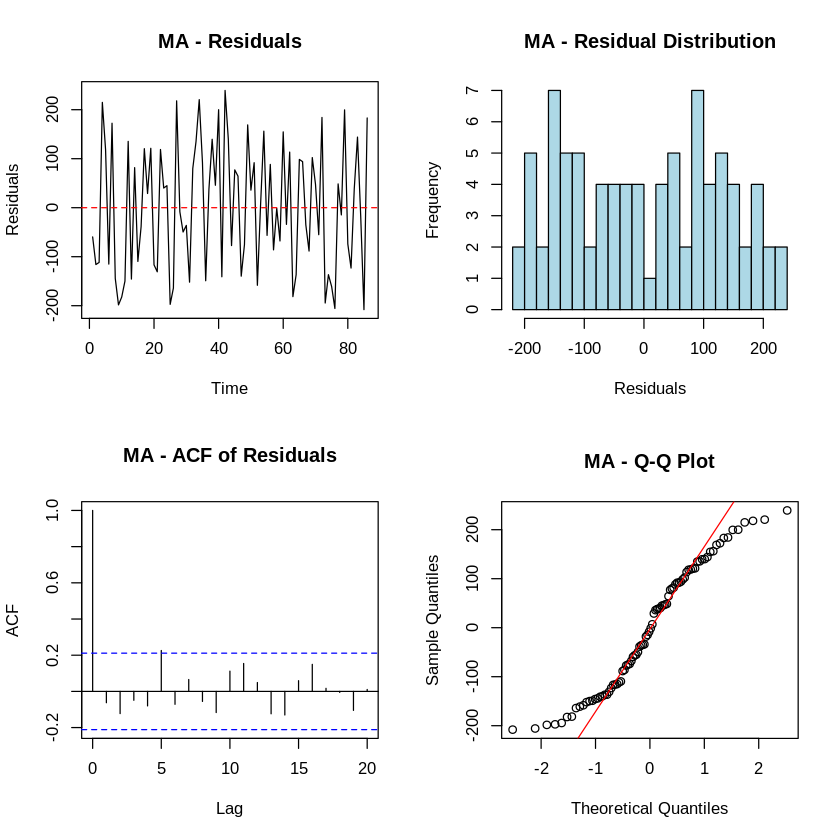


 ARMA - Ljung-Box Test Results:
Lag 10 - p-value: 0.5792 
Lag 20 - p-value: 0.5717 
=> Residuals appear to be white noise

Checking residuals for ARIMA model:

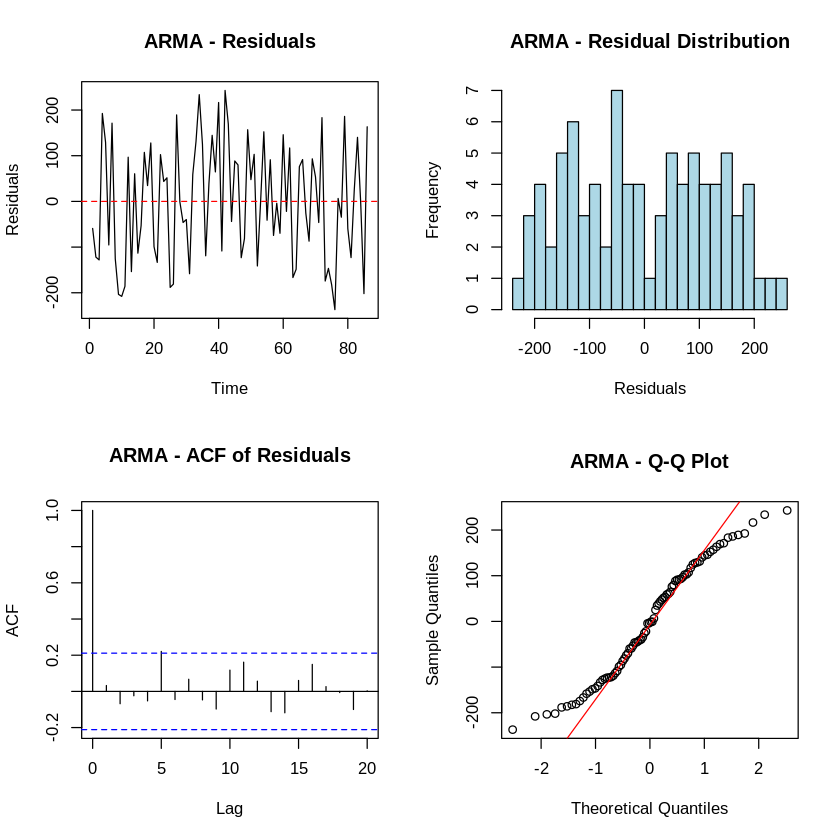


 ARIMA - Ljung-Box Test Results:
Lag 10 - p-value: 0.3529 
Lag 20 - p-value: 0.3887 
=> Residuals appear to be white noise

STEP 6: Model Comparison
 ---------------------------------------- 

Model Performance Comparison:
  Model    Order     AIC     BIC     RMSE
1    AR      p=0 1081.86 1086.77 152.4189
2    MA      q=0 1081.86 1086.77 152.4189
3  ARMA p=1, q=1 1084.43 1094.25 153.0376
4 ARIMA  (0,0,0) 1081.86 1086.77 152.4189

Best Model by RMSE: AR (RMSE: 152.4189 )
Best Model by AIC: AR (AIC: 1081.86 )

Results saved to 'model_comparison_results.csv'

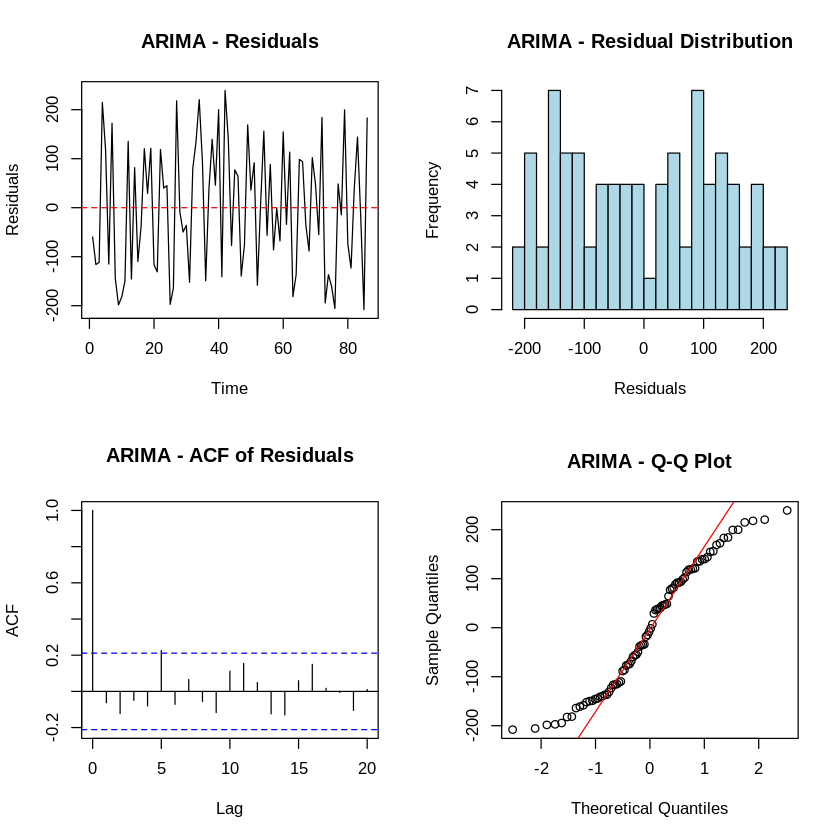

In [ ]:

# Time Series Analysis using Box-Jenkins Methodology
# Load required libraries
library(ggplot2)
library(tseries)
library(forecast)
library(gridExtra)
library(lmtest)
library(reshape2)

# Set seed for reproducibility
set.seed(42)

# ============================================================================
# 1. DATA LOADING AND PREPARATION
# ============================================================================

load_and_prepare_data <- function(file_path = "//content//sample_data//projectdata.csv") {
  # Load time series data - either from file or generate sample data
  if (!is.null(file_path)) {
    # Load your data here (adjust based on your file format)
    data <- read.csv(file_path)
    # Assuming first column is date, second column is values
    ts_data <- ts(data[,1], start = c(2017, 1), frequency = 12)
  } else {

   print("Some error occured")
  }

  return(ts_data)
}

# ============================================================================
# 2. STATIONARITY TESTING
# ============================================================================

check_stationarity <- function(timeseries, series_name) {
  # Perform ADF test for stationarity
  # Remove NA values
  timeseries <- na.omit(timeseries)

  # ADF test
  adf_result <- adf.test(timeseries, alternative = "stationary")

  cat("\n", series_name, "- Augmented Dickey-Fuller Test:\n")
  cat("ADF Statistic:", round(adf_result$statistic, 4), "\n")
  cat("p-value:", round(adf_result$p.value, 4), "\n")

  if (adf_result$p.value <= 0.05) {
    cat("=> Series is stationary\n")
    return(TRUE)
  } else {
    cat("=> Series is non-stationary\n")
    return(FALSE)
  }
}

# ============================================================================
# 3. MODEL IDENTIFICATION PLOTS
# ============================================================================

plot_identification <- function(ts_data, max_lag = 20) {
  # Create ACF and PACF plots for model identification
  # Calculate differences
  ts_diff <- diff(ts_data)

  # Set up plotting area
  par(mfrow = c(2, 2))

  # Original series
  plot(ts_data, main = "Original Time Series",
       ylab = "Value", xlab = "Time", col = "blue")

  # ACF of original
  acf(ts_data, lag.max = max_lag, main = "ACF - Original Series")

  # PACF of differenced
  pacf(ts_diff, lag.max = max_lag, main = "PACF - Differenced Series")

  # ACF of differenced
  acf(ts_diff, lag.max = max_lag, main = "ACF - Differenced Series")

  # Reset plotting parameters
  par(mfrow = c(1, 1))
}

# ============================================================================
# 4. MODEL FITTING AND EVALUATION
# ============================================================================

fit_and_evaluate_models <- function(ts_data, train_ratio = 0.8) {
  # Fit different time series models and compare performance
  # Split data into training and testing
  n <- length(ts_data)
  split_point <- floor(n * train_ratio)

  train <- ts_data[1:split_point]
  test <- ts_data[(split_point + 1):n]

  # Store results
  results <- data.frame(
    Model = character(),
    Order = character(),
    AIC = numeric(),
    BIC = numeric(),
    RMSE = numeric(),
    stringsAsFactors = FALSE
  )

  models <- list()

  cat("\n", paste(rep("=", 60), collapse = ""))
  cat("\nFITTING DIFFERENT TIME SERIES MODELS")
  cat("\n", paste(rep("=", 60), collapse = ""), "\n")

  # 1. AR Model (Automatic order selection using AIC)
  tryCatch({
    ar_fit <- auto.arima(train, max.p = 5, max.q = 0,
                         max.d = 0, seasonal = FALSE,
                         ic = "aic")

    ar_forecast <- forecast(ar_fit, h = length(test))
    ar_rmse <- sqrt(mean((test - ar_forecast$mean)^2))

    models[["AR"]] <- ar_fit
    results <- rbind(results, data.frame(
      Model = "AR",
      Order = paste0("p=", ar_fit$arma[1]),
      AIC = round(ar_fit$aic, 2),
      BIC = round(ar_fit$bic, 2),
      RMSE = round(ar_rmse, 4)
    ))

    cat("\nAR Model (Order p=", ar_fit$arma[1], "):")
    cat("\nAIC:", round(ar_fit$aic, 2),
        " BIC:", round(ar_fit$bic, 2),
        " RMSE:", round(ar_rmse, 4), "\n")
  }, error = function(e) {
    cat("\nAR model failed:", e$message, "\n")
  })

  # 2. MA Model
  tryCatch({
    ma_fit <- auto.arima(train, max.p = 0, max.q = 5,
                         max.d = 0, seasonal = FALSE,
                         ic = "aic")

    ma_forecast <- forecast(ma_fit, h = length(test))
    ma_rmse <- sqrt(mean((test - ma_forecast$mean)^2))

    models[["MA"]] <- ma_fit
    results <- rbind(results, data.frame(
      Model = "MA",
      Order = paste0("q=", ma_fit$arma[2]),
      AIC = round(ma_fit$aic, 2),
      BIC = round(ma_fit$bic, 2),
      RMSE = round(ma_rmse, 4)
    ))

    cat("\nMA Model (Order q=", ma_fit$arma[2], "):")
    cat("\nAIC:", round(ma_fit$aic, 2),
        " BIC:", round(ma_fit$bic, 2),
        " RMSE:", round(ma_rmse, 4), "\n")
  }, error = function(e) {
    cat("\nMA model failed:", e$message, "\n")
  })

  # 3. ARMA Model (p=1, q=1)
  tryCatch({
    arma_fit <- Arima(train, order = c(1, 0, 1))

    arma_forecast <- forecast(arma_fit, h = length(test))
    arma_rmse <- sqrt(mean((test - arma_forecast$mean)^2))

    models[["ARMA"]] <- arma_fit
    results <- rbind(results, data.frame(
      Model = "ARMA",
      Order = "p=1, q=1",
      AIC = round(arma_fit$aic, 2),
      BIC = round(arma_fit$bic, 2),
      RMSE = round(arma_rmse, 4)
    ))

    cat("\nARMA Model (p=1, q=1):\n")
    cat("\nAIC:", round(arma_fit$aic, 2),
        " BIC:", round(arma_fit$bic, 2),
        " RMSE:", round(arma_rmse, 4), "\n")
  }, error = function(e) {
    cat("\nARMA model failed:", e$message, "\n")
  })

  # 4. ARIMA Model (automatic selection)
  tryCatch({
    arima_fit <- auto.arima(train, max.p = 3, max.q = 3,
                            max.d = 1, seasonal = FALSE,
                            ic = "aic", stepwise = FALSE)

    arima_forecast <- forecast(arima_fit, h = length(test))
    arima_rmse <- sqrt(mean((test - arima_forecast$mean)^2))

    models[["ARIMA"]] <- arima_fit
    results <- rbind(results, data.frame(
      Model = "ARIMA",
      Order = paste0("(", arima_fit$arma[1], ",",
                    arima_fit$arma[6], ",", arima_fit$arma[2], ")"),
      AIC = round(arima_fit$aic, 2),
      BIC = round(arima_fit$bic, 2),
      RMSE = round(arima_rmse, 4)
    ))

    cat("\nARIMA Model (Order:",
        paste0("(", arima_fit$arma[1], ",",
              arima_fit$arma[6], ",", arima_fit$arma[2], "):\n"))
    cat("\nAIC:", round(arima_fit$aic, 2),
        " BIC:", round(arima_fit$bic, 2),
        " RMSE:", round(arima_rmse, 4), "\n")
  }, error = function(e) {
    cat("\nARIMA model failed:", e$message, "\n")
  })

  # Create prediction plot
  plot_predictions(train, test, models)

  return(list(models = models, results = results))
}

# ============================================================================
# 5. PREDICTION PLOT
# ============================================================================

plot_predictions <- function(train, test, models) {
  # Plot actual vs predicted values from all models
  n_train <- length(train)
  n_test <- length(test)

  # Create time indices
  time_index <- 1:(n_train + n_test)

  # Create data frame for plotting
  plot_data <- data.frame(
    Time = time_index,
    Actual = c(train, test),
    Type = c(rep("Train", n_train), rep("Test", n_test))
  )

  # Add predictions
  colors <- c("AR" = "red", "MA" = "blue", "ARMA" = "green", "ARIMA" = "purple")

  p <- ggplot(plot_data, aes(x = Time, y = Actual)) +
    geom_line(aes(color = Type), linewidth = 0.8) +
    geom_point(aes(color = Type), size = 1) +
    scale_color_manual(values = c("Train" = "black", "Test" = "orange")) +
    labs(title = "Model Predictions vs Actual Values",
         x = "Time", y = "Value") +
    theme_minimal() +
    theme(legend.position = "bottom")

  # Add model predictions
  for (model_name in names(models)) {
    # Get fitted values for the training data.
    # Note: fitted() might not return values for all n_train points,
    # depending on the model's initialization or differencing.
    fitted_vals <- fitted(models[[model_name]])

    # Get forecast values for the test data
    forecast_vals <- forecast(models[[model_name]], h = n_test)$mean

    # Construct the full prediction sequence for plotting.
    # It includes NA padding for any parts of the training data not covered by fitted_vals,
    # followed by fitted_vals, and then forecast_vals.
    # This ensures the total length is n_train + n_test.
    full_prediction_series <- c(
      rep(NA, n_train - length(fitted_vals)), # Pad with NAs if fitted_vals is shorter than train
      fitted_vals,
      forecast_vals
    )

    # Ensure full_prediction_series has the correct length before creating the data frame
    # If there's still a mismatch (unlikely with this logic, but for robustness),
    # we will adjust it to match the expected length.
    if (length(full_prediction_series) != (n_train + n_test)) {
      warning(paste("Length mismatch for model", model_name, "prediction series. Expected",
                    n_train + n_test, "got", length(full_prediction_series)))
      # Truncate or extend with NA if length is off
      if (length(full_prediction_series) > (n_train + n_test)) {
        full_prediction_series <- head(full_prediction_series, n_train + n_test)
      } else {
        full_prediction_series <- c(full_prediction_series, rep(NA, (n_train + n_test) - length(full_prediction_series)))
      }
    }


    pred_df <- data.frame(Time = time_index, Value = full_prediction_series)
    p <- p + geom_line(data = pred_df, aes(x = Time, y = Value,
                                           color = model_name),
                      linetype = "dashed", linewidth = 0.7) +
         scale_color_manual(values = c(colors,
                                       "Train" = "black",
                                       "Test" = "orange"))
  }

  print(p)
}

# ============================================================================
# 6. RESIDUAL DIAGNOSTICS
# ============================================================================

check_residuals <- function(model, model_name) {
  # Perform residual diagnostics
  residuals <- residuals(model)

  # Set up plotting area
  par(mfrow = c(2, 2))

  # 1. Residuals over time
  plot(residuals, type = "l", main = paste(model_name, "- Residuals"),
       ylab = "Residuals", xlab = "Time")
  abline(h = 0, col = "red", lty = 2)

  # 2. Histogram of residuals
  hist(residuals, main = paste(model_name, "- Residual Distribution"),
       xlab = "Residuals", col = "lightblue", border = "black",
       breaks = 20)

  # 3. ACF of residuals
  acf(residuals, main = paste(model_name, "- ACF of Residuals"),
      lag.max = 20)

  # 4. Q-Q plot
  qqnorm(residuals, main = paste(model_name, "- Q-Q Plot"))
  qqline(residuals, col = "red")

  # Reset plotting parameters
  par(mfrow = c(1, 1))

  # Ljung-Box test
  lb_test <- Box.test(residuals, lag = 10, type = "Ljung-Box")
  lb_test20 <- Box.test(residuals, lag = 20, type = "Ljung-Box")

  cat("\n", model_name, "- Ljung-Box Test Results:\n")
  cat("Lag 10 - p-value:", round(lb_test$p.value, 4), "\n")
  cat("Lag 20 - p-value:", round(lb_test20$p.value, 4), "\n")

  if (lb_test$p.value > 0.05 & lb_test20$p.value > 0.05) {
    cat("=> Residuals appear to be white noise\n")
  } else {
    cat("=> Residuals may contain remaining autocorrelation\n")
  }
}

# ============================================================================
# 7. MAIN FUNCTION
# ============================================================================

main <- function() {
  cat(paste(rep("=", 60), collapse = ""))
  cat("\nBOX-JENKINS METHODOLOGY FOR TIME SERIES ANALYSIS")
  cat("\n", paste(rep("=", 60), collapse = ""), "\n")

  # Step 1: Load data
  cat("\nSTEP 1: Loading Time Series Data")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  # Replace with your file path or use generated data
  ts_data <- load_and_prepare_data()  # Add file_path='your_data.csv' to load actual data

  cat("Data loaded:", length(ts_data), "observations\n")
  cat("Date range:", start(ts_data)[1], "to", end(ts_data)[1], "\n")

  # Step 2: Check stationarity
  cat("\nSTEP 2: Testing for Stationarity")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  is_stationary <- check_stationarity(ts_data, "Original Series")

  # Step 3: Identification
  cat("\nSTEP 3: Model Identification")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  plot_identification(ts_data)

  if (!is_stationary) {
    cat("\nApplying differencing to achieve stationarity...\n")
    ts_diff <- diff(ts_data)
    check_stationarity(ts_diff, "Differenced Series")
  }

  # Step 4: Model Estimation and Fitting
  cat("\nSTEP 4: Model Estimation and Fitting")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  results_list <- fit_and_evaluate_models(ts_data)
  models <- results_list$models
  results_df <- results_list$results

  # Step 5: Diagnostic Checking
  cat("\nSTEP 5: Diagnostic Checking")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  for (model_name in names(models)) {
    cat("\nChecking residuals for", model_name, "model:")
    check_residuals(models[[model_name]], model_name)
  }

  # Step 6: Model Comparison
  cat("\nSTEP 6: Model Comparison")
  cat("\n", paste(rep("-", 40), collapse = ""), "\n")

  cat("\nModel Performance Comparison:\n")
  print(results_df)

  # Identify best model
  if (nrow(results_df) > 0) {
    best_rmse <- results_df[which.min(results_df$RMSE), ]
    best_aic <- results_df[which.min(results_df$AIC), ]

    cat("\nBest Model by RMSE:", best_rmse$Model,
        "(RMSE:", round(best_rmse$RMSE, 4), ")")
    cat("\nBest Model by AIC:", best_aic$Model,
        "(AIC:", round(best_aic$AIC, 2), ")")

    # Save results to CSV
    write.csv(results_df, "model_comparison_results.csv", row.names = FALSE)
    cat("\n\nResults saved to 'model_comparison_results.csv'")
  }
}

# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# Install required packages if not already installed
required_packages <- c("ggplot2", "tseries", "forecast", "gridExtra", "lmtest")
for (pkg in required_packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg)
    library(pkg, character.only = TRUE)
  }
}

# Run the main function
main()

# To load your own data, replace the line in main() with:
# ts_data <- load_and_prepare_data(file_path = "your_data.csv")
